In [1]:
import pandas as pd
import json
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from transformer_lens import HookedTransformer
from collections import Counter
from transformer_lens import utils
import numpy as np

2026-03-02 12:43:05.245612: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-02 12:43:05.291782: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-02 12:43:06.355750: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/ubuntu/minicon

In [2]:
model = HookedTransformer.from_pretrained("gpt2-xl")
# model.eval()

for name, param in model.named_parameters():
    print(name)

`torch_dtype` is deprecated! Use `dtype` instead!


KeyboardInterrupt: 

In [ ]:
rephrased_stereoset = json.load(open('data/stereoset/rephrased_stereoset.json'))
print(f"Loaded {len(rephrased_stereoset)} examples.")

In [ ]:
df = pd.read_csv("outputs/gpt2-xl/draft/out_with_heads_final_merged.csv")

EXPECTED_LAYERS = 48

group_cols = ['ID', 'Candidate']
if 'Token_Position' in df.columns:
    group_cols.append('Token_Position')
elif 'Candidate_First_Token' in df.columns and df['Candidate_First_Token'].nunique() > df['Candidate'].nunique():
    group_cols.append('Candidate_First_Token')

print(f"Checking completeness grouping by: {group_cols}")

counts = df.groupby(group_cols)['Layer'].count()
unique_layers = df.groupby(group_cols)['Layer'].nunique()

missing_data = unique_layers[unique_layers != EXPECTED_LAYERS]

if len(missing_data) == 0:
    print("\n✅ SUCCESS: All items have exactly 48 layers processed.")
    print(f"Total Unique Items Processed: {len(unique_layers)}")
else:
    print(f"\n❌ WARNING: {len(missing_data)} items are incomplete.")
    print("Sample of incomplete items (ID, Candidate, Layer_Count):")
    print(missing_data.head(10))

    if missing_data.mean() == 1:
        print("\n⚠️ CRITICAL WARNING: Most items have only 1 layer.")
        print("You likely ran the script with the 'Loop Overwrite' bug (saving outside the loop).")


In [3]:
df_probability_info = pd.read_csv("outputs/gpt2-xl/dev_tests/out_DLA_gender_test.csv")
df_accumulated_impact = pd.read_csv("outputs/gpt2-xl/dev_tests/accumulated_impact_gender_test.csv")
# df_probability_info = pd.read_csv("outputs/gpt2-xl/dev_tests/out_DLA_gender_train.csv")
# df_accumulated_impact = pd.read_csv("outputs/gpt2-xl/dev_tests/accumulated_impact_gender_train.csv")


df_probability_info_gender_fine_tuned = pd.read_csv("outputs/gpt2-xl/fine_tuned/out_DLA_gender_test_fine_tuned_attn_10.csv")
df_accumulated_impact_gender_fine_tuned = pd.read_csv("outputs/gpt2-xl/fine_tuned/accumulated_impact_gender_test_fine_tuned_attn_10.csv")

df_probability_info = df_probability_info[df_probability_info['ID'].isin(df_probability_info_gender_fine_tuned['ID'])]
df_accumulated_impact = df_accumulated_impact[df_accumulated_impact['ID'].isin(df_accumulated_impact_gender_fine_tuned['ID'])]
# df_probability_info_gender_fine_tuned = pd.read_csv("outputs/gpt2-xl/out_DLA_gender_fine_tuned_test.csv")
# df_accumulated_impact_gender_fine_tuned = pd.read_csv("outputs/gpt2-xl/accumulated_impact_gender_fine_tuned_test.csv")

In [ ]:
df_probability_info = df_probability_info[['ID', 'Prompt', 'Candidate', 'Token_Str',
'Token_Position', 'Is_First_Token', 'Type', 'Layer',
'Layer_Accumulated_Prob', 'Token_Instant_Prob', 'MLP_Logit_Impact',
'Head_0', 'Head_1', 'Head_2', 'Head_3', 'Head_4', 'Head_5', 'Head_6',
'Head_7', 'Head_8', 'Head_9', 'Head_10', 'Head_11', 'Head_12',
'Head_13', 'Head_14', 'Head_15', 'Head_16', 'Head_17', 'Head_18',
'Head_19', 'Head_20', 'Head_21', 'Head_22', 'Head_23', 'Head_24']]

In [ ]:
df_accumulated_impact

In [4]:
print(set(df_probability_info_gender_fine_tuned['ID'].unique().tolist()) == set(df_probability_info['ID'].unique().tolist()))
print(set(df_accumulated_impact_gender_fine_tuned['ID'].unique().tolist()) == set(df_accumulated_impact['ID'].unique().tolist()))

print(set(df_probability_info_gender_fine_tuned['ID'].unique().tolist()) == set(df_accumulated_impact_gender_fine_tuned['ID'].unique().tolist()))
print(set(df_probability_info['ID'].unique().tolist()) == set(df_accumulated_impact['ID'].unique().tolist()))

print(len(set(df_probability_info_gender_fine_tuned['ID'].unique().tolist())), len(set(df_probability_info['ID'].unique().tolist())))
print(len(set(df_accumulated_impact_gender_fine_tuned['ID'].unique().tolist())),len( set(df_accumulated_impact['ID'].unique().tolist())))

print(len(set(df_probability_info_gender_fine_tuned['ID'].unique().tolist())), len(set(df_accumulated_impact_gender_fine_tuned['ID'].unique().tolist())))
print(len(set(df_probability_info['ID'].unique().tolist())), len(set(df_accumulated_impact['ID'].unique().tolist())))


True
True
True
True
151 151
151 151
151 151
151 151


## Comparison of impact and probabilities of original and fine-tuned models

In [ ]:
file_path = "data/stereoset/dev.json"
with open(file_path, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

df_main = df_accumulated_impact.copy()

full_intrasentence_list = raw_data.get('data', {}).get('intrasentence', [])
id_to_biastype = {item['id']: item['bias_type'] for item in full_intrasentence_list}

# Map Bias Type
df_main['Bias_Type'] = df_main['ID'].map(id_to_biastype).fillna('unknown')
print(f"Bias Types Found: {df_main['Bias_Type'].unique()}")

In [ ]:
max_layer = df_final['Layer'].max()

last_token_indices = df_final.groupby(['ID', 'Type'])['Token_Position'].transform('max') == df_final['Token_Position']

final_probs = df_probability_info[
    (df_probability_info['Layer'] == max_layer) &
    (last_token_indices)
    ].copy()

final_probs = final_probs.drop_duplicates(subset=['ID', 'Type'])

In [ ]:
final_probs

In [ ]:
import numpy as np

prob_pivot = final_probs.pivot(index='ID', columns='Type', values='Layer_Accumulated_Prob')

# add logic for anti-stereotype and unrelated
conditions = [
    (prob_pivot['stereotype'] > prob_pivot['anti-stereotype']) & (prob_pivot['stereotype'] > prob_pivot['unrelated']),
    (prob_pivot['anti-stereotype'] > prob_pivot['stereotype']) & (prob_pivot['anti-stereotype'] > prob_pivot['unrelated']),
    (prob_pivot['unrelated'] > prob_pivot['stereotype']) & (prob_pivot['unrelated'] > prob_pivot['anti-stereotype'])
]
choices = ['stereotype', 'anti-stereotype', 'unrelated']

prob_pivot['Winner_Type'] = np.select(conditions, choices, default='tie')

id_to_winner = prob_pivot['Winner_Type'].to_dict()
df_main['Model_Preference'] = df_main['ID'].map(id_to_winner)

print(f"Model preference calculated. Processed {len(prob_pivot)} unique IDs.")

In [5]:
import matplotlib.ticker as ticker
def generate_grouped_analysis(sub_df,
                              scenario_title,
                              all_probs_df,
                              winner_type):
    if len(sub_df) == 0:
        return

    # 1. Prepare Data
    # ----------------
    relevant_ids = sub_df['ID'].unique()
    current_probs = all_probs_df[all_probs_df['ID'].isin(relevant_ids)].copy()

    type_map = {'stereotype': 'Stereotype', 'anti-stereotype': 'Anti-Stereotype', 'unrelated': 'Unrelated'}
    current_probs['Type'] = current_probs['Type'].map(type_map).fillna(current_probs['Type'])
    plot_df = sub_df.copy()
    plot_df['Type'] = plot_df['Type'].map(type_map).fillna(plot_df['Type'])

    winner_label = type_map.get(winner_type, winner_type)

    # MLP Data
    mlp_df = plot_df[plot_df['Component'] == 'MLP']
    mlp_summary = mlp_df.groupby(['Layer', 'Type'])['Accumulated_Impact'].mean().reset_index()

    # Probability Bars Data
    prob_summary = current_probs.groupby(['Layer', 'Type'])['Layer_Accumulated_Prob'].mean().reset_index()
    prob_summary_winner = prob_summary[prob_summary['Type'] == winner_label]

    # Head Data
    head_df = plot_df[plot_df['Component'].str.startswith('Head')].copy()
    head_df['Head_ID'] = head_df['Component'].str.replace('Head_', '').astype(int)

    # Heatmap Data (Transposed: Rows=Heads, Cols=Layers)
    heatmap_data = head_df[head_df['Type'] == winner_label]
    # We pivot so Heads are Index (Y) and Layers are Columns (X)
    head_matrix = heatmap_data.groupby(['Head_ID', 'Layer'])['Accumulated_Impact'].mean().unstack()

    # Head Sum Data
    head_layer_sum = head_df.groupby(['ID', 'Layer', 'Type'])['Accumulated_Impact'].sum().reset_index()
    head_sum_summary = head_layer_sum.groupby(['Layer', 'Type'])['Accumulated_Impact'].mean().reset_index()

    # 2. Plotting
    # ----------------
    # Create Figure with GridSpec
    fig = plt.figure(figsize=(16, 10))

    # Height ratios: Top row = 1, Bottom row = 0.8 (since heatmap is wider, it doesn't need to be as tall)
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 0.8])

    ax_mlp = fig.add_subplot(gs[0, 0])      # Top Left
    ax_sum = fig.add_subplot(gs[0, 1])      # Top Right
    ax_heat = fig.add_subplot(gs[1, :])     # Bottom (Spans width)

    # --- PLOT 1 (Top Left): MLP Impact + Probability Bars ---
    ax_mlp_twin = ax_mlp.twinx()

    # Bar Plot (Secondary Axis)
    sns.barplot(
        data=prob_summary_winner,
        x='Layer',
        y='Layer_Accumulated_Prob',
        color='gray',
        alpha=0.3,
        ax=ax_mlp_twin,
        errorbar=None
    )
    ax_mlp_twin.set_ylabel(f"Prob ({winner_label})")
    ax_mlp_twin.grid(False)
    ax_mlp_twin.set_xticks([])

    sns.lineplot(
        data=mlp_summary,
        x='Layer',
        y='Accumulated_Impact',
        hue='Type',
        marker='o',
        linewidth=2,
        ax=ax_mlp
    )

    ax_mlp.set_title("MLP Impact + Winner Probability (Grey Bars)")
    ax_mlp.set_ylabel("Cumulative Logit Contribution")

    ax_mlp.xaxis.grid(False)
    ax_mlp.yaxis.grid(True, alpha=0.3)

    ax_mlp.xaxis.set_major_locator(ticker.MultipleLocator(5))
    ax_mlp.legend(title="Logit Impact", loc='upper left')

    sns.lineplot(
        data=head_sum_summary,
        x='Layer',
        y='Accumulated_Impact',
        hue='Type',
        marker='o',
        ax=ax_sum
    )
    ax_sum.set_title("Total Attention Block Impact\n(Sum of Heads)")
    ax_sum.set_ylabel("Cumulative Logit Contribution")
    ax_sum.grid(True, alpha=0.3)
    ax_sum.xaxis.set_major_locator(ticker.MultipleLocator(5))

    sns.heatmap(
        head_matrix,
        cmap="RdBu_r",
        center=0,
        ax=ax_heat,
        cbar_kws={'label': f'Impact on "{winner_label}" Logit'}
    )

    ax_heat.set_title(f"Detailed Head Impact Heatmap (Target: {winner_label})")
    ax_heat.set_xlabel("Layer")
    ax_heat.set_ylabel("Head Index")

    ax_heat.xaxis.set_major_locator(ticker.MultipleLocator(5))
    ax_heat.xaxis.set_major_formatter(ticker.ScalarFormatter())

    plt.suptitle(scenario_title, fontsize=18, y=0.98)
    plt.tight_layout()
    plt.show()

In [10]:
import gc

import pandas as pd
import numpy as np

def processing(df_accumulated_impact,
               df_probability_info,
               fine_tuned=False,
               margin=1e-5
            ):

    if 'Layer_Accumulated_Prob' in df_accumulated_impact.columns:
        df_accumulated_impact = df_accumulated_impact.drop(columns=['Layer_Accumulated_Prob'])


    idx_max_tokens = df_probability_info.groupby(['ID', 'Type', 'Layer'])['Token_Position'].idxmax()

    prob_lookup = df_probability_info.loc[idx_max_tokens, ['ID', 'Type', 'Layer', 'Layer_Accumulated_Prob']].copy()

    df_accumulated_impact = pd.merge(
        df_accumulated_impact,
        prob_lookup,
        on=['ID', 'Type', 'Layer'],
        how='left'
    )

    # --- WINNER CALCULATION ---
    max_layer = df_accumulated_impact['Layer'].max()
    last_token_indices = df_probability_info.groupby(['ID', 'Type'])['Token_Position'].transform('max') == df_probability_info['Token_Position']

    final_probs = df_probability_info[
        (df_probability_info['Layer'] == max_layer) &
        (last_token_indices)
        ].copy()

    if fine_tuned:
        final_probs = final_probs[
            (final_probs['Type'] == 'stereotype') |
            (final_probs['Type'] == 'anti-stereotype') |
            (final_probs['Type'] == 'unrelated')
        ]

    final_probs['Base_Type'] = final_probs['Type'].apply(lambda x: x.split('-')[0].split('_')[0])
    grouped_probs = final_probs.groupby(['ID', 'Base_Type'])['Layer_Accumulated_Prob'].max().reset_index()

    prob_pivot = grouped_probs.pivot(index='ID',
                                     columns='Base_Type',
                                     values='Layer_Accumulated_Prob').fillna(0)

    cols = prob_pivot.columns
    s_col = next((c for c in cols if 'stereo' in c and 'anti' not in c), None)
    a_col = next((c for c in cols if 'anti' in c), None)
    u_col = next((c for c in cols if 'unrelated' in c), None)

    conditions = []
    choices = []

    if s_col and a_col and u_col:
        # Check if the winner beats BOTH alternatives by at least the margin
        conditions = [
            (prob_pivot[s_col] - prob_pivot[a_col] > margin) & (prob_pivot[s_col] - prob_pivot[u_col] > margin),
            (prob_pivot[a_col] - prob_pivot[s_col] > margin) & (prob_pivot[a_col] - prob_pivot[u_col] > margin),
            (prob_pivot[u_col] - prob_pivot[s_col] > margin) & (prob_pivot[u_col] - prob_pivot[a_col] > margin)
        ]
        choices = ['stereotype', 'anti-stereotype', 'unrelated']
    elif s_col and a_col:
        conditions = [
            (prob_pivot[s_col] - prob_pivot[a_col] > margin),
            (prob_pivot[a_col] - prob_pivot[s_col] > margin)
        ]
        choices = ['stereotype', 'anti-stereotype']

    if conditions:
        # Anything that doesn't beat the margin defaults to 'neutral'
        prob_pivot['Winner_Type'] = np.select(conditions, choices, default='neutral')
    else:
        prob_pivot['Winner_Type'] = 'unknown'

    id_to_winner_original = prob_pivot['Winner_Type'].to_dict()

    df_accumulated_impact['Model_Preference'] = df_accumulated_impact['ID'].map(id_to_winner_original)

    return df_accumulated_impact



def compare_and_plot(df_original_probability_info,
                     df_original_accumulated_impact,
                     df_gender_fine_tuned_probability_info,
                     df_gender_fine_tuned_accumulated_impact,
                     scenario_title,
                     bias_type):

    file_path = "data/stereoset/test.json"
    with open(file_path, 'r', encoding='utf-8') as f:
        raw_data = json.load(f)

    full_intrasentence_list = raw_data.get('data', {}).get('intrasentence', [])
    id_to_biastype = {item['id']: item['bias_type'] for item in full_intrasentence_list}

    # 1. Map Bias Types
    for df_prob, df_impact in [
        (df_original_probability_info, df_original_accumulated_impact),
        (df_gender_fine_tuned_probability_info, df_gender_fine_tuned_accumulated_impact)
    ]:
        df_prob['Bias_Type'] = df_prob['ID'].map(id_to_biastype).fillna('unknown')
        df_impact['Bias_Type'] = df_impact['ID'].map(id_to_biastype).fillna('unknown')

    # 2. Process Data (Calculate Winners & Merge Probabilities)
    df_orig = processing(df_original_accumulated_impact, df_original_probability_info)
    df_tuned = processing(df_gender_fine_tuned_accumulated_impact, df_gender_fine_tuned_probability_info, fine_tuned=True)

    # 3. Filter for specific Bias Type
    df_orig = df_orig[df_orig['Bias_Type'] == bias_type]
    df_tuned = df_tuned[df_tuned['Bias_Type'] == bias_type]

    if df_orig.empty or df_tuned.empty:
        print(f"No data found for bias type '{bias_type}'.")
        return

    # --- PLOT 1: Global Counts ---
    orig_counts = df_orig[['ID', 'Model_Preference']].drop_duplicates()['Model_Preference'].value_counts().reset_index()
    orig_counts['Model'] = 'Original'

    tuned_counts = df_tuned[['ID', 'Model_Preference']].drop_duplicates()['Model_Preference'].value_counts().reset_index()
    tuned_counts['Model'] = 'Fine-Tuned'

    comparison_counts = pd.concat([orig_counts, tuned_counts])
    if 'index' in comparison_counts.columns:
        comparison_counts = comparison_counts.rename(columns={'index': 'Preference_Type', 'Model_Preference': 'Count'})
    else:
        comparison_counts.columns = ['Preference_Type', 'Count', 'Model']

    plt.figure(figsize=(10, 6))
    sns.barplot(data=comparison_counts, x='Preference_Type', y='Count', hue='Model', palette='muted')
    plt.title(f"Global Preference Counts: Original vs Fine-Tuned ({bias_type})")
    plt.ylabel("Number of Examples")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    # --- PLOT 2: Transition Analysis ---
    orig_winners = df_orig[['ID', 'Model_Preference']].drop_duplicates().set_index('ID')
    tuned_winners = df_tuned[['ID', 'Model_Preference']].drop_duplicates().set_index('ID')

    comparison_map = orig_winners.join(tuned_winners, lsuffix='_Orig', rsuffix='_Tuned')
    stereotype_ids = comparison_map[comparison_map['Model_Preference_Orig'] == 'stereotype'].index

    if len(stereotype_ids) > 0:
        outcome_counts = comparison_map.loc[stereotype_ids, 'Model_Preference_Tuned'].value_counts()
        plt.figure(figsize=(8, 5))
        sns.barplot(x=outcome_counts.index, y=outcome_counts.values, palette='viridis')
        plt.title(f"Fate of Originally Biased Examples ({bias_type})\n(N={len(stereotype_ids)} originally stereotype)")
        plt.xlabel("New Model Preference")
        plt.ylabel("Count")
        plt.show()
    else:
        print("Original model had 0 stereotype preferences for this bias type.")

    max_layer = df_orig['Layer'].max()

    # --- PLOT 3 (NEW): Layerwise Probability Comparison ---

    def get_layerwise_trend(df, model_label):
        condition = (df['Type'].str.contains('stereotype')) & (~df['Type'].str.contains('anti'))
        subset = df[condition].copy()

        # 2. Drop duplicates: The dataframe has one row per HEAD (many rows per layer).
        # We only need one probability value per ID per Layer.
        subset = subset[['ID', 'Layer', 'Layer_Accumulated_Prob']].drop_duplicates()

        subset['Model'] = model_label
        return subset

    # Extract trends
    trend_orig = get_layerwise_trend(df_orig, 'Original')
    trend_tuned = get_layerwise_trend(df_tuned, 'Fine-Tuned')

    # Combine
    trend_combined = pd.concat([trend_orig, trend_tuned])

    plt.figure(figsize=(10, 6))
    # sns.lineplot calculates the mean and 95% confidence interval automatically
    sns.lineplot(data=trend_combined, x='Layer', y='Layer_Accumulated_Prob', hue='Model', palette=['red', 'blue'])

    plt.title(f"Average Stereotype Probability Evolution by Layer ({bias_type})")
    plt.xlabel("Layer Index")
    plt.ylabel("Accumulated Probability (Stereotype Token)")
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- PLOT 4: Final Layer Scatter ---
    def get_stereo_probs(df_in):
        last_layer = df_in[df_in['Layer'] == max_layer]

        stereo_rows = last_layer[
            (last_layer['Type'].str.contains('stereotype')) &
            (~last_layer['Type'].str.contains('anti'))
        ]
        stereo_rows = stereo_rows.sort_values('Layer_Accumulated_Prob', ascending=False)
        return stereo_rows.drop_duplicates(subset=['ID'])[['ID', 'Layer_Accumulated_Prob']]

    probs_orig = get_stereo_probs(df_orig)
    probs_tuned = get_stereo_probs(df_tuned)

    prob_comparison = pd.merge(probs_orig, probs_tuned, on='ID', suffixes=('_Orig', '_Tuned'))

    plt.figure(figsize=(8, 8))
    sns.scatterplot(data=prob_comparison, x='Layer_Accumulated_Prob_Orig', y='Layer_Accumulated_Prob_Tuned', alpha=0.6)

    limit = max(prob_comparison['Layer_Accumulated_Prob_Orig'].max(), prob_comparison['Layer_Accumulated_Prob_Tuned'].max())
    plt.plot([0, limit], [0, limit], 'r--', label='No Change')

    plt.title(f"Final Layer Stereotype Probability Comparison ({bias_type})\nPoints below line = Reduced Bias")
    plt.xlabel("Original Probability")
    plt.ylabel("Fine-Tuned Probability")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    del raw_data
    gc.collect()

In [11]:
df_probability_info

,ID,Prompt,Candidate,Token_Str,Token_Position,Is_First_Token,Type,Layer,Layer_Accumulated_Prob,Token_Instant_Prob,...,Head_16,Head_17,Head_18,Head_19,Head_20,Head_21,Head_22,Head_23,Head_24,Bias_Type
0,d2d849cd314659695c35bc02e503b42a,"The reasons they call her that are several, ma...",girl,girl,0,True,stereotype,0,8.025668e-06,0.000008,...,0.000508,-0.000275,0.014629,-0.000865,-0.004076,-0.000529,0.023969,-0.004968,-0.004538,gender
1,d2d849cd314659695c35bc02e503b42a,"The reasons they call her that are several, ma...",girl,girl,0,True,stereotype,1,2.443478e-05,0.000024,...,-0.003078,-0.130663,0.045952,-0.019478,-0.034707,0.078985,0.031623,0.010463,-0.024719,gender
2,d2d849cd314659695c35bc02e503b42a,"The reasons they call her that are several, ma...",girl,girl,0,True,stereotype,2,5.072321e-05,0.000051,...,0.012956,-0.192867,-0.057764,0.165002,0.043069,-0.163181,0.146734,0.030938,-0.100787,gender
3,d2d849cd314659695c35bc02e503b42a,"The reasons they call her that are several, ma...",girl,girl,0,True,stereotype,3,8.280276e-05,0.000083,...,-0.050390,-0.153475,-0.000391,-0.190779,0.087129,0.011906,-0.425283,0.013058,-0.121892,gender
4,d2d849cd314659695c35bc02e503b42a,"The reasons they call her that are several, ma...",girl,girl,0,True,stereotype,4,8.845975e-05,0.000088,...,-0.044183,-0.253159,-0.023112,0.420576,-0.246501,-0.163058,0.496530,-0.073344,0.087617,gender
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27067,162638f7983a2de2685cc47ec3c01927,The man insisted on being called sir and was a...,aristocratic,ocratic,1,False,stereotype,43,2.240867e-07,0.944872,...,-0.032125,0.020901,-0.140920,0.019573,0.134487,0.114716,0.996610,0.026133,0.008440,gender
27068,162638f7983a2de2685cc47ec3c01927,The man insisted on being called sir and was a...,aristocratic,ocratic,1,False,stereotype,44,2.471412e-07,0.946617,...,-0.068893,0.012314,-0.138801,0.062760,-0.247208,-0.009255,-0.000103,-0.159486,-0.043845,gender
27069,162638f7983a2de2685cc47ec3c01927,The man insisted on being called sir and was a...,aristocratic,ocratic,1,False,stereotype,45,3.923332e-07,0.929276,...,-0.026512,-0.354931,0.069432,0.098113,-0.018921,-0.018203,-0.042698,0.008711,-0.050945,gender
27070,162638f7983a2de2685cc47ec3c01927,The man insisted on being called sir and was a...,aristocratic,ocratic,1,False,stereotype,46,7.135474e-07,0.939676,...,0.242379,-0.049149,0.331772,0.152463,-0.217562,-0.078444,0.046721,0.020175,-0.044973,gender


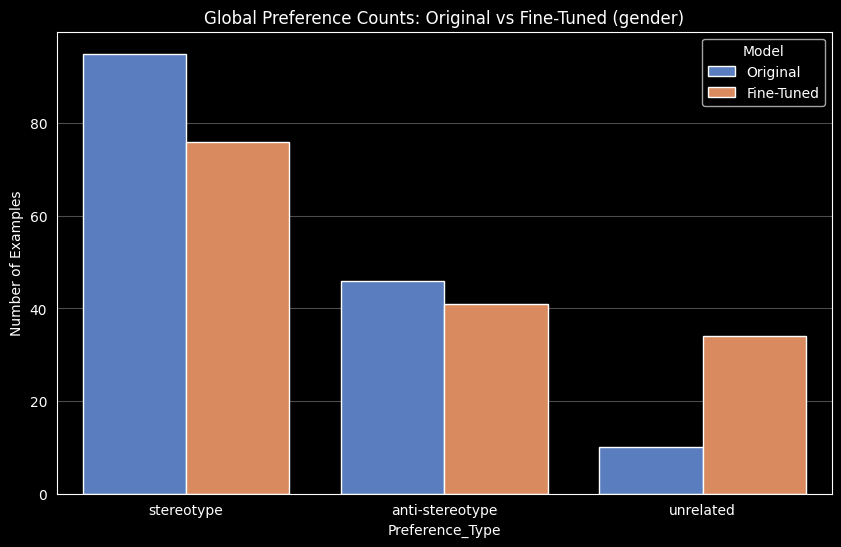

/tmp/ipykernel_35680/1865893660.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=outcome_counts.index, y=outcome_counts.values, palette='viridis')


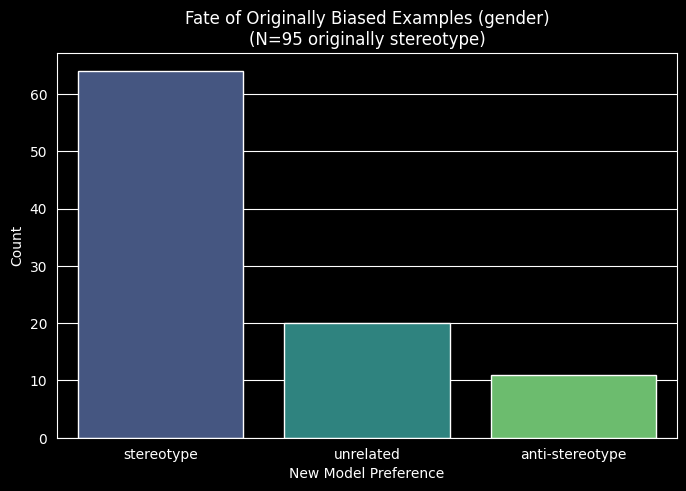

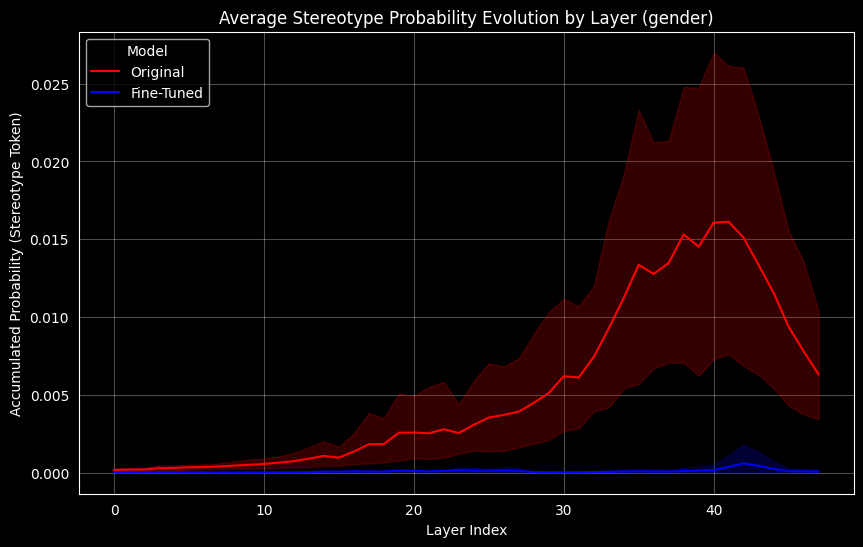

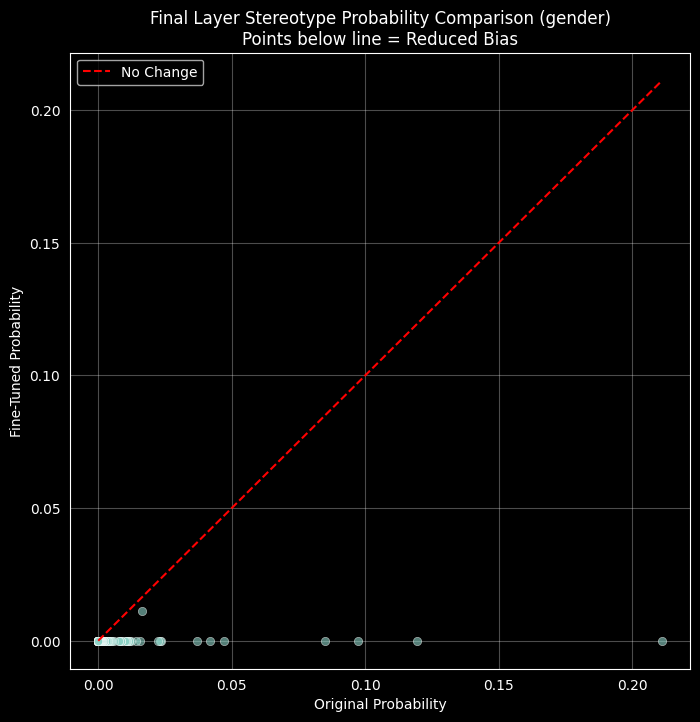

In [9]:
compare_and_plot(df_original_probability_info=df_probability_info,
                 df_original_accumulated_impact=df_accumulated_impact,
                 df_gender_fine_tuned_probability_info=df_probability_info_gender_fine_tuned,
                 df_gender_fine_tuned_accumulated_impact=df_accumulated_impact_gender_fine_tuned,
                 scenario_title="Gender Fine-Tuned Model",
                 bias_type="gender")

In [80]:
df_probability_info = pd.read_csv("outputs/gpt2-xl/dev_tests/out_DLA_gender_test.csv")
df_accumulated_impact = pd.read_csv("outputs/gpt2-xl/dev_tests/accumulated_impact_gender_test.csv")

df_probability_info_gender_fine_tuned = pd.read_csv("outputs/gpt2-xl/fine_tuned/out_DLA_gender_test_fine_tuned_attn_1.csv")
df_accumulated_impact_gender_fine_tuned = pd.read_csv("outputs/gpt2-xl/fine_tuned/accumulated_impact_gender_test_fine_tuned_attn_1.csv")

df_probability_info = df_probability_info[df_probability_info['ID'].isin(df_probability_info_gender_fine_tuned['ID'])]
df_accumulated_impact = df_accumulated_impact[df_accumulated_impact['ID'].isin(df_accumulated_impact_gender_fine_tuned['ID'])]

In [81]:
max_layer = df_probability_info['Layer'].max()

last_token_indices = df_probability_info.groupby(['ID', 'Type'])['Token_Position'].transform('max') == df_probability_info['Token_Position']

final_probs = df_probability_info[
    (df_probability_info['Layer'] == 47) &
    (last_token_indices)
    ].copy()

final_probs = final_probs.drop_duplicates(subset=['ID', 'Type'])

prob_pivot = final_probs.pivot(index='ID', columns='Type', values='Layer_Accumulated_Prob')

# add logic for anti-stereotype and unrelated
conditions = [
    (prob_pivot['stereotype'] > prob_pivot['anti-stereotype']) & (prob_pivot['stereotype'] > prob_pivot['unrelated']),
    (prob_pivot['anti-stereotype'] > prob_pivot['stereotype']) & (prob_pivot['anti-stereotype'] > prob_pivot['unrelated']),
    (prob_pivot['unrelated'] > prob_pivot['stereotype']) & (prob_pivot['unrelated'] > prob_pivot['anti-stereotype'])
]
choices = ['stereotype', 'anti-stereotype', 'unrelated']

prob_pivot['Winner_Type'] = np.select(conditions, choices, default='tie')

id_to_winner = prob_pivot['Winner_Type'].to_dict()
df_accumulated_impact['Model_Preference'] = df_accumulated_impact['ID'].map(id_to_winner)

In [82]:
max_layer = df_probability_info_gender_fine_tuned['Layer'].max()

last_token_indices = df_probability_info_gender_fine_tuned.groupby(['ID', 'Type'])['Token_Position'].transform('max') == df_probability_info_gender_fine_tuned['Token_Position']

final_probs = df_probability_info_gender_fine_tuned[
    (df_probability_info_gender_fine_tuned['Layer'] == 47) &
    (last_token_indices)
    ].copy()

final_probs = final_probs.drop_duplicates(subset=['ID', 'Type'])

prob_pivot = final_probs.pivot(index='ID', columns='Type', values='Layer_Accumulated_Prob')

# add logic for anti-stereotype and unrelated
conditions = [
    (prob_pivot['stereotype'] > prob_pivot['anti-stereotype']) & (prob_pivot['stereotype'] > prob_pivot['unrelated']),
    (prob_pivot['anti-stereotype'] > prob_pivot['stereotype']) & (prob_pivot['anti-stereotype'] > prob_pivot['unrelated']),
    (prob_pivot['unrelated'] > prob_pivot['stereotype']) & (prob_pivot['unrelated'] > prob_pivot['anti-stereotype'])
]
choices = ['stereotype', 'anti-stereotype', 'unrelated']

prob_pivot['Winner_Type'] = np.select(conditions, choices, default='tie')

id_to_winner = prob_pivot['Winner_Type'].to_dict()
df_accumulated_impact_gender_fine_tuned['Model_Preference'] = df_accumulated_impact_gender_fine_tuned['ID'].map(id_to_winner)

--- Analyzing Bias Type: GENDER ---


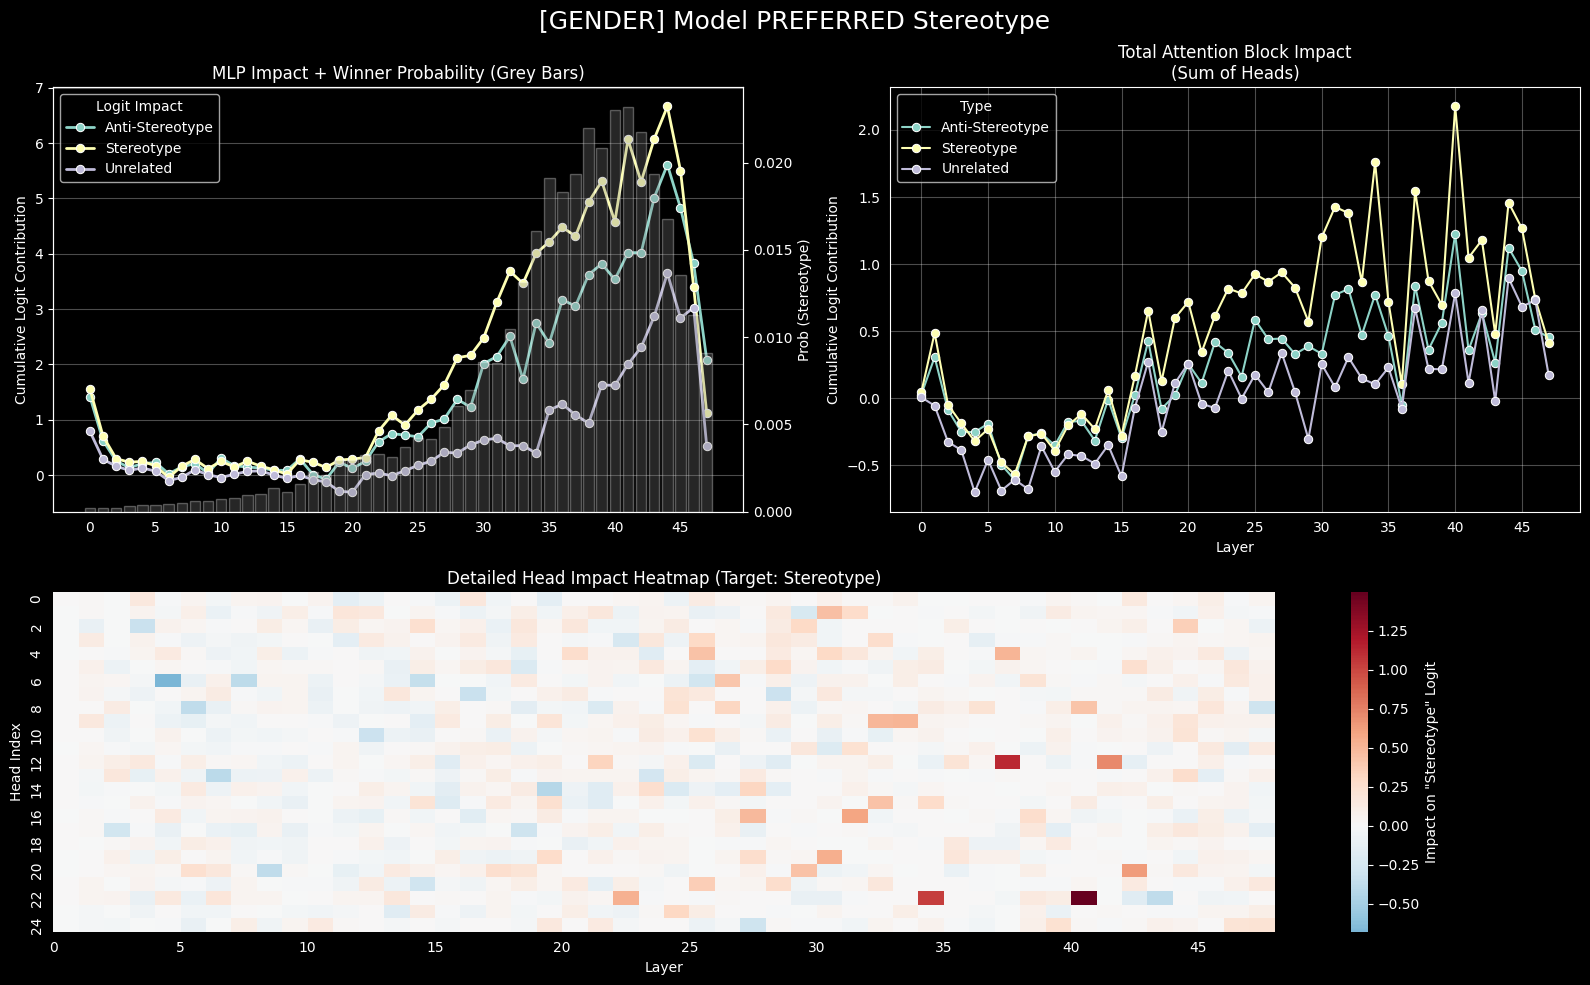

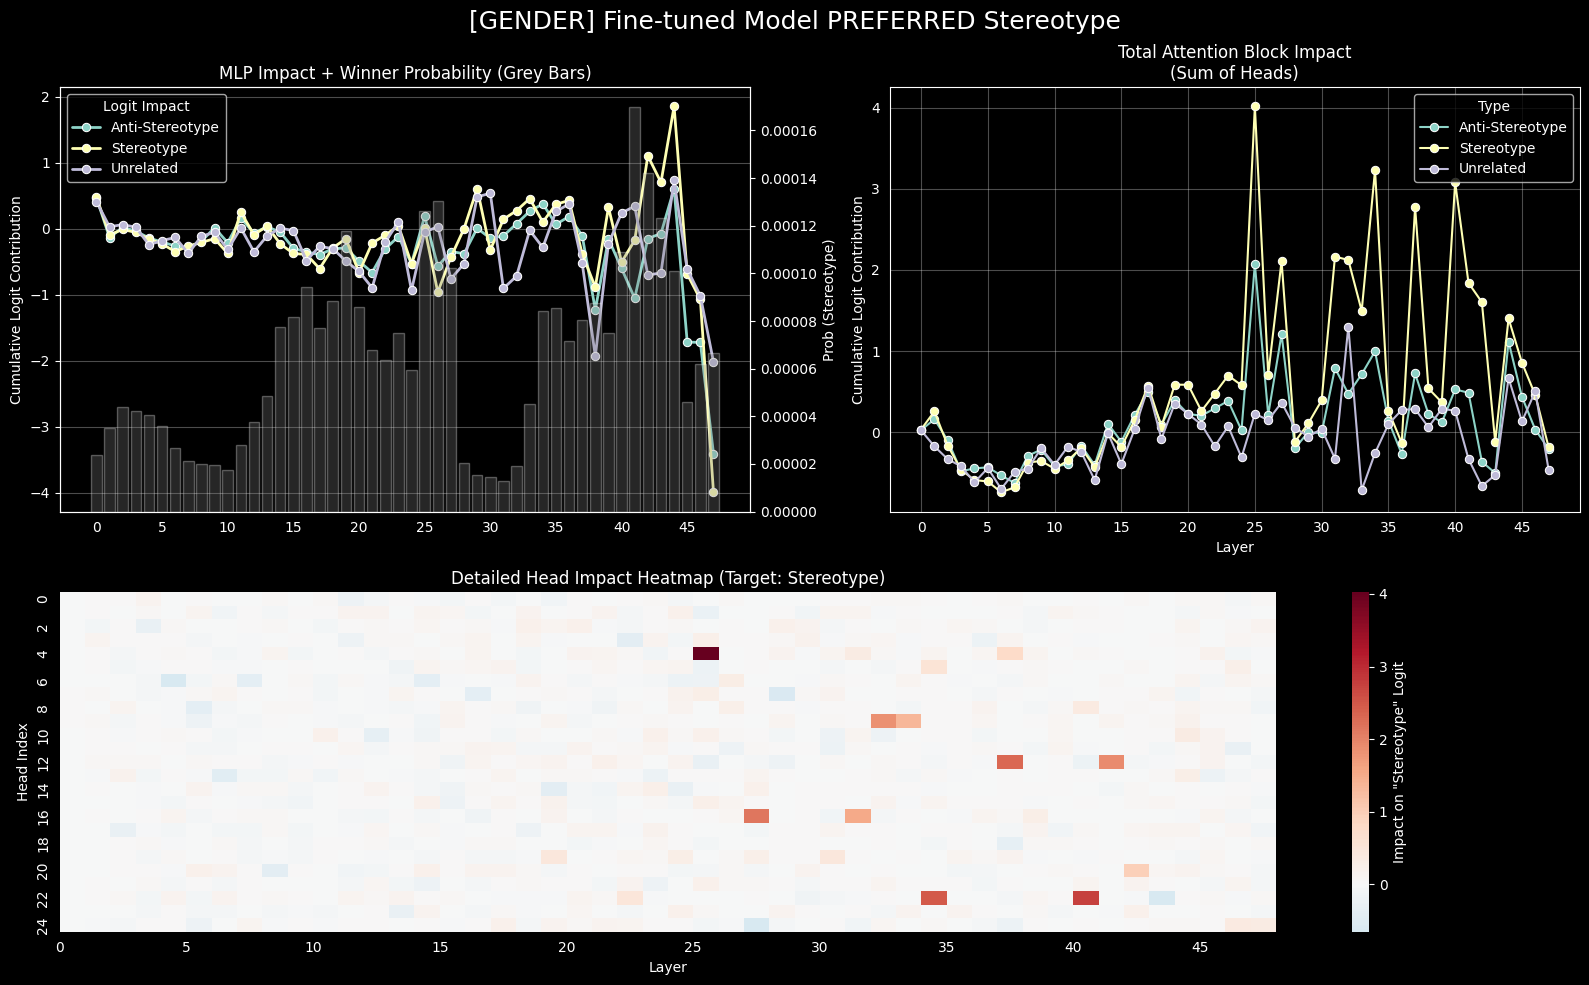

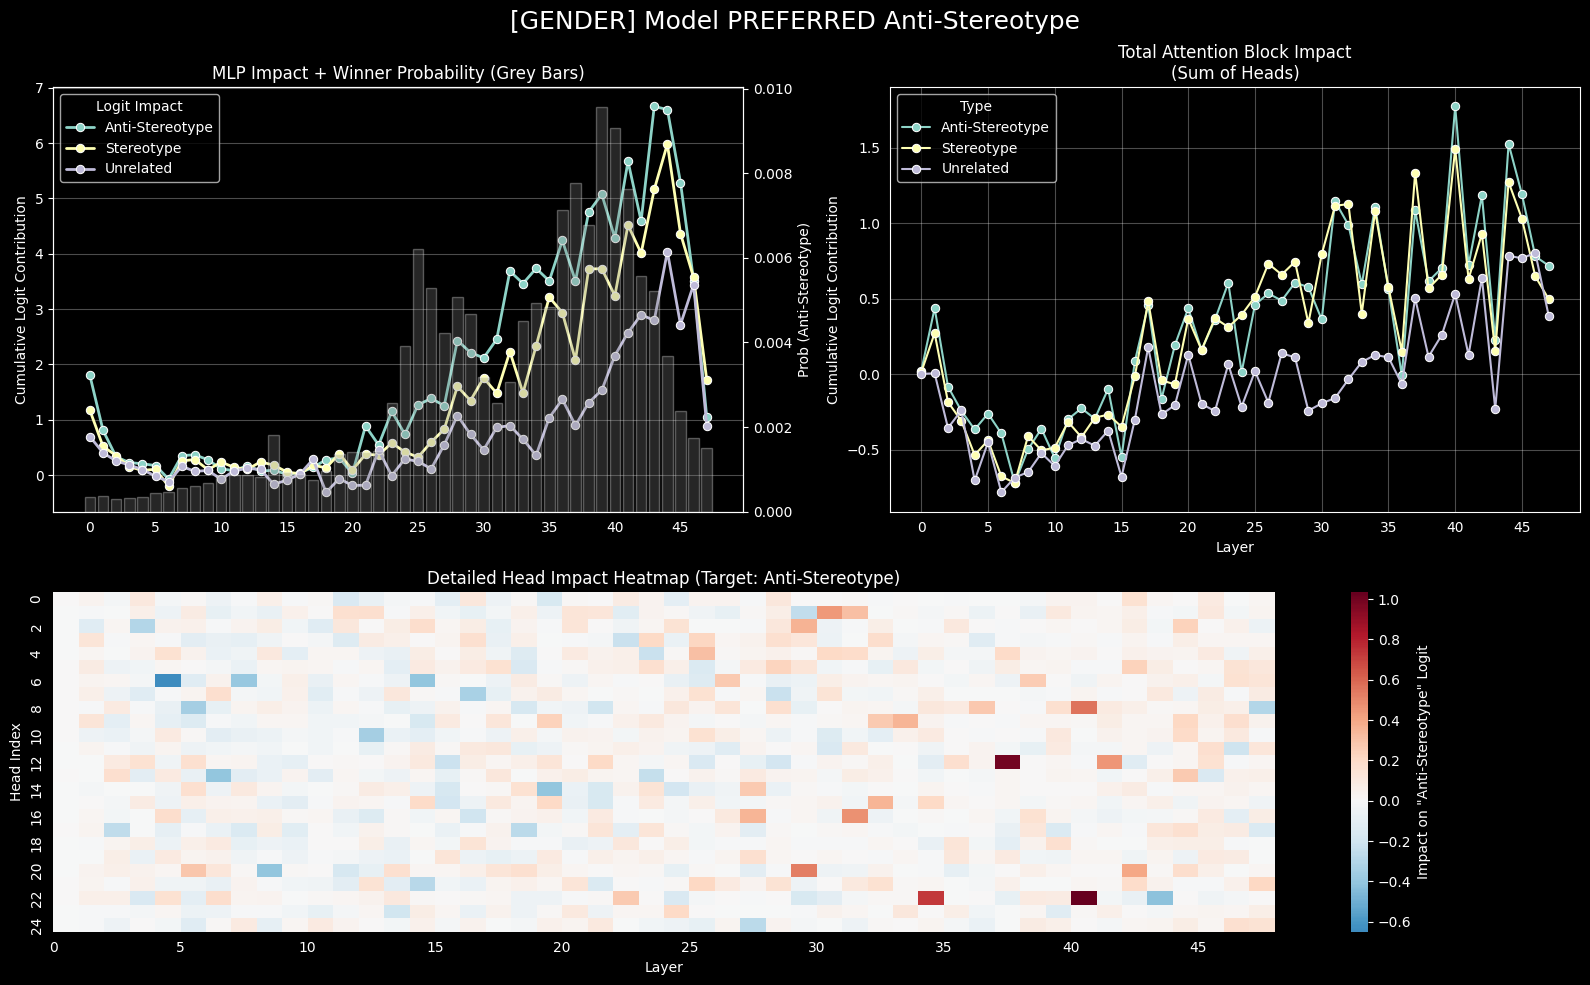

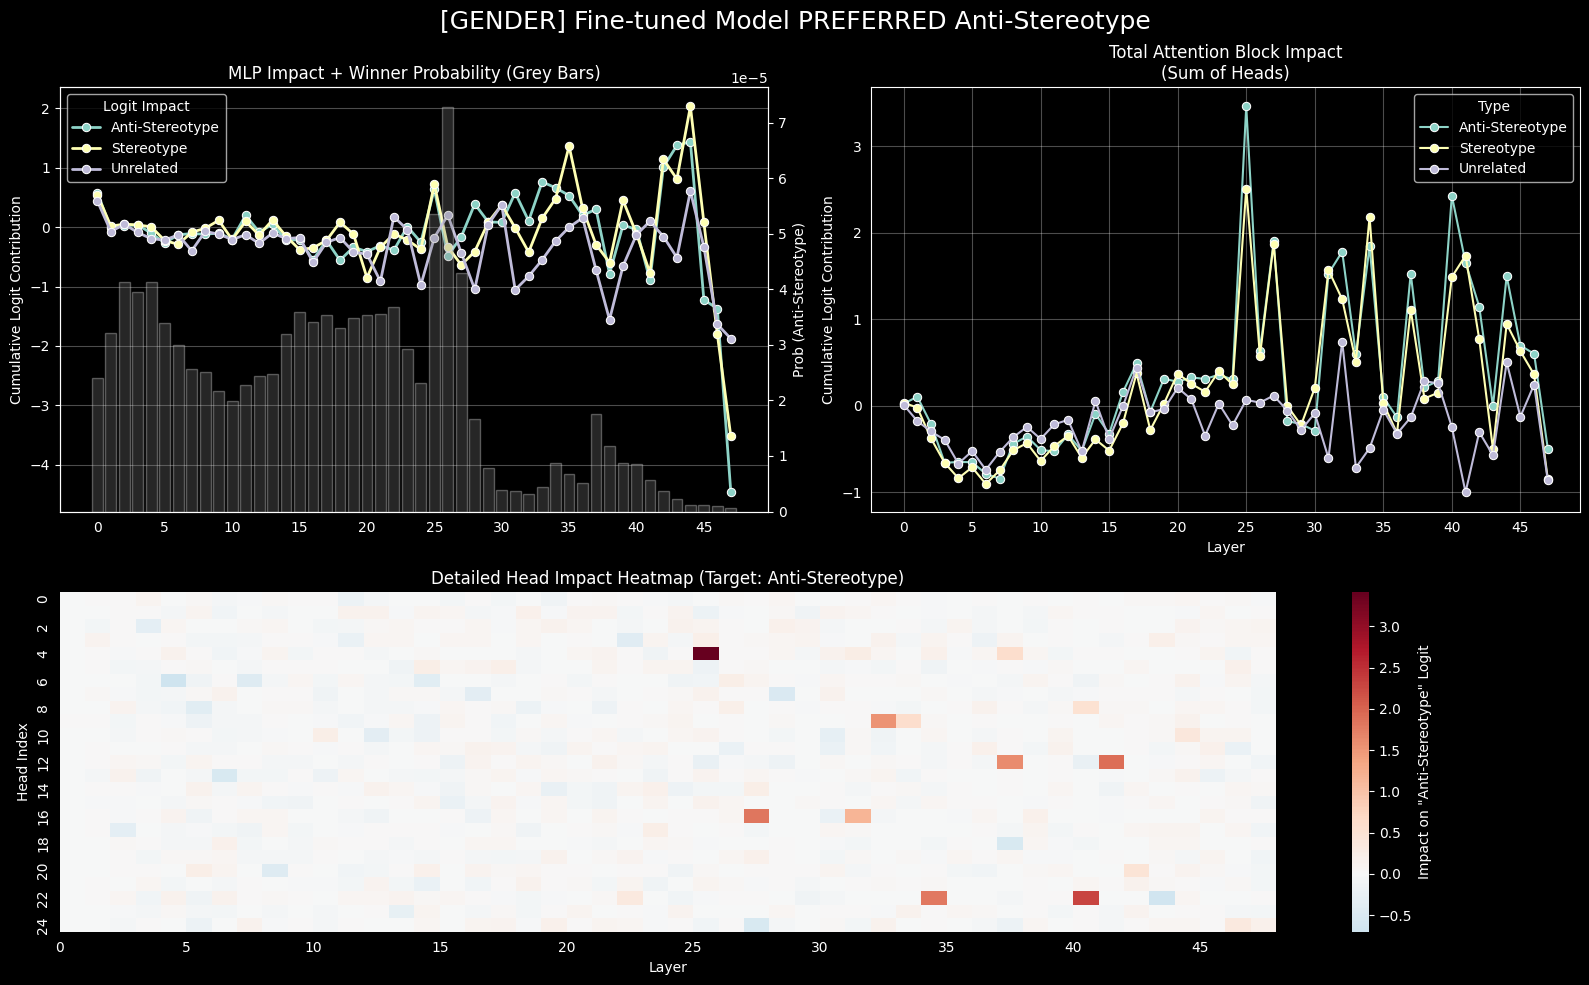

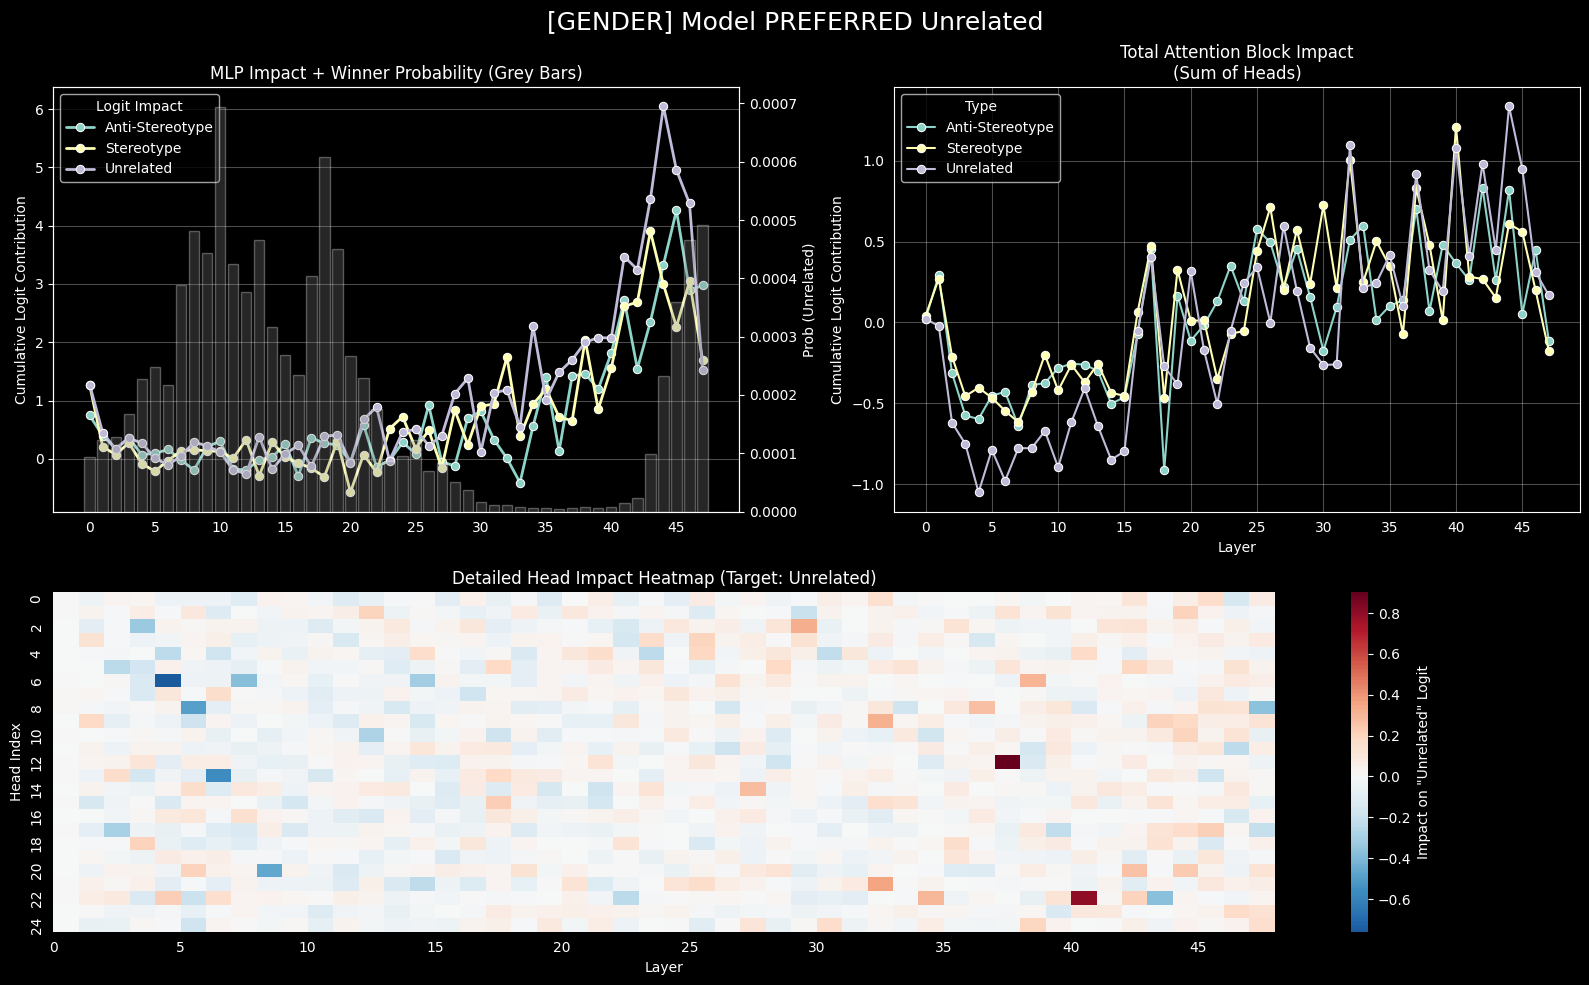

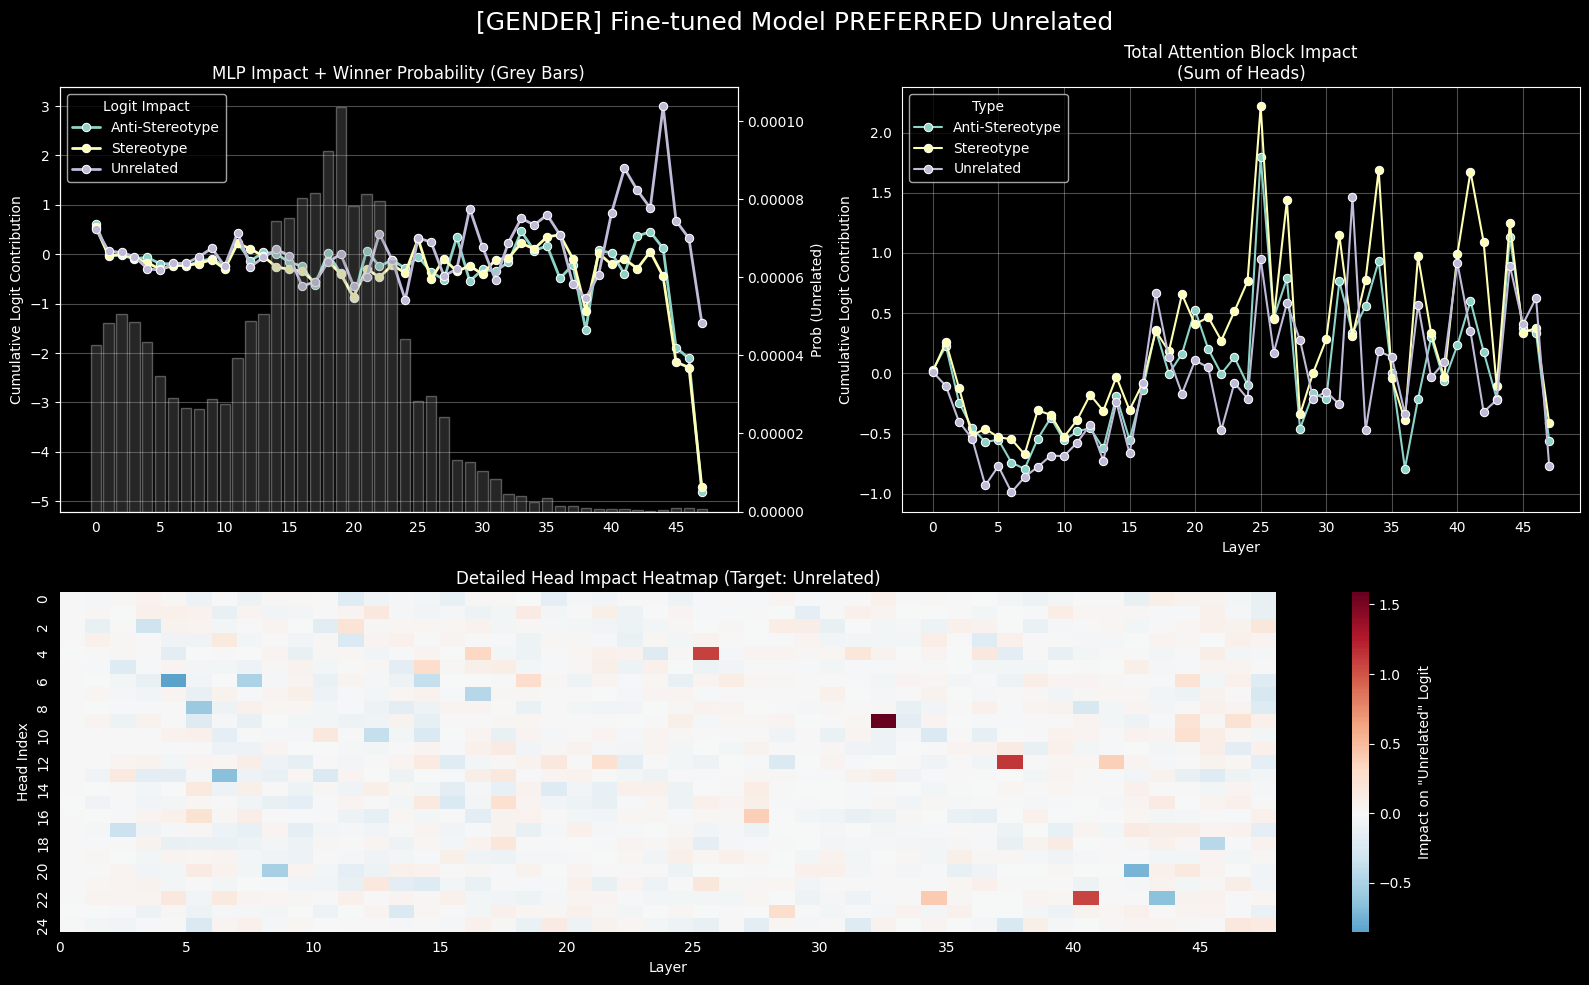

In [83]:
# bias_types = [b for b in df_probability_info['Bias_Type'].unique() if b != 'unknown']
for bias_type in ['gender']:
    print(f"--- Analyzing Bias Type: {bias_type.upper()} ---")

    # Scenario 1: Model Chose Stereotype
    df_stereo = df_accumulated_impact[
        # (df_accumulated_impact['Bias_Type'] == bias_type) &
        (df_accumulated_impact['Model_Preference'] == 'stereotype')
        ]
    if len(df_stereo) > 0:
        generate_grouped_analysis(sub_df=df_stereo,
                                  scenario_title=f"[{bias_type.upper()}] Model PREFERRED Stereotype",
                                  winner_type='stereotype',
                                  all_probs_df=df_probability_info)

    df_stereo = df_accumulated_impact_gender_fine_tuned[
        # (df_accumulated_impact['Bias_Type'] == bias_type) &
        (df_accumulated_impact_gender_fine_tuned['Model_Preference'] == 'stereotype')
        ]
    if len(df_stereo) > 0:
        generate_grouped_analysis(sub_df=df_stereo,
                                  scenario_title=f"[{bias_type.upper()}] Fine-tuned Model PREFERRED Stereotype",
                                  winner_type='stereotype',
                                  all_probs_df=df_probability_info_gender_fine_tuned)

    # Scenario 2: Model Chose Anti-Stereotype
    df_anti = df_accumulated_impact[
        # (df_accumulated_impact['Bias_Type'] == bias_type) &
        (df_accumulated_impact['Model_Preference'] == 'anti-stereotype')
        ]
    if len(df_anti) > 0:
        generate_grouped_analysis(sub_df=df_anti,
                                  scenario_title=f"[{bias_type.upper()}] Model PREFERRED Anti-Stereotype",
                                  winner_type='anti-stereotype',
                                  all_probs_df=df_probability_info)

    df_anti = df_accumulated_impact_gender_fine_tuned[
        # (df_accumulated_impact['Bias_Type'] == bias_type) &
        (df_accumulated_impact_gender_fine_tuned['Model_Preference'] == 'anti-stereotype')
        ]
    if len(df_anti) > 0:
        generate_grouped_analysis(sub_df=df_anti,
                                  scenario_title=f"[{bias_type.upper()}] Fine-tuned Model PREFERRED Anti-Stereotype",
                                  winner_type='anti-stereotype',
                                  all_probs_df=df_probability_info_gender_fine_tuned)

    df_unrelated = df_accumulated_impact[
        # (df_accumulated_impact['Bias_Type'] == bias_type) &
        (df_accumulated_impact['Model_Preference'] == 'unrelated')
        ]
    if len(df_unrelated) > 0:
        generate_grouped_analysis(sub_df=df_unrelated,
                                  scenario_title=f"[{bias_type.upper()}] Model PREFERRED Unrelated",
                                  winner_type='unrelated',
                                  all_probs_df=df_probability_info)

    df_unrelated = df_accumulated_impact_gender_fine_tuned[
        # (df_accumulated_impact['Bias_Type'] == bias_type) &
        (df_accumulated_impact_gender_fine_tuned['Model_Preference'] == 'unrelated')
        ]
    if len(df_unrelated) > 0:
        generate_grouped_analysis(sub_df=df_unrelated,
                                  scenario_title=f"[{bias_type.upper()}] Fine-tuned Model PREFERRED Unrelated",
                                  winner_type='unrelated',
                                  all_probs_df=df_probability_info_gender_fine_tuned)

Plotting MLP Analysis...


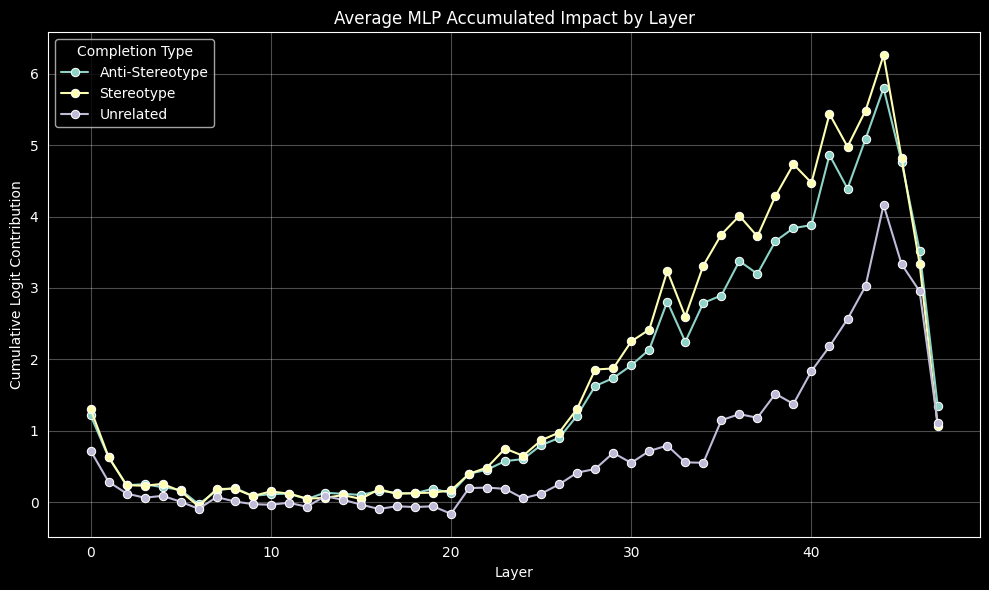

In [9]:
df = pd.read_csv("outputs/gpt2-xl/dev_tests/accumulated_impact_gender_train.csv")

type_map = {
    'stereotype': 'Stereotype',
    'anti-stereotype': 'Anti-Stereotype',
    'unrelated': 'Unrelated'
}
df['Type'] = df['Type'].map(type_map).fillna(df['Type'])

print("Plotting MLP Analysis...")
mlp_df = df[df['Component'] == 'MLP'].copy()

mlp_summary = mlp_df.groupby(['Layer', 'Type'])['Accumulated_Impact'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=mlp_summary, x='Layer', y='Accumulated_Impact', hue='Type', marker='o')
plt.title("Average MLP Accumulated Impact by Layer")
plt.ylabel("Cumulative Logit Contribution")
plt.xlabel("Layer")
plt.grid(True, alpha=0.3)
plt.legend(title="Completion Type")
plt.tight_layout()
plt.show()

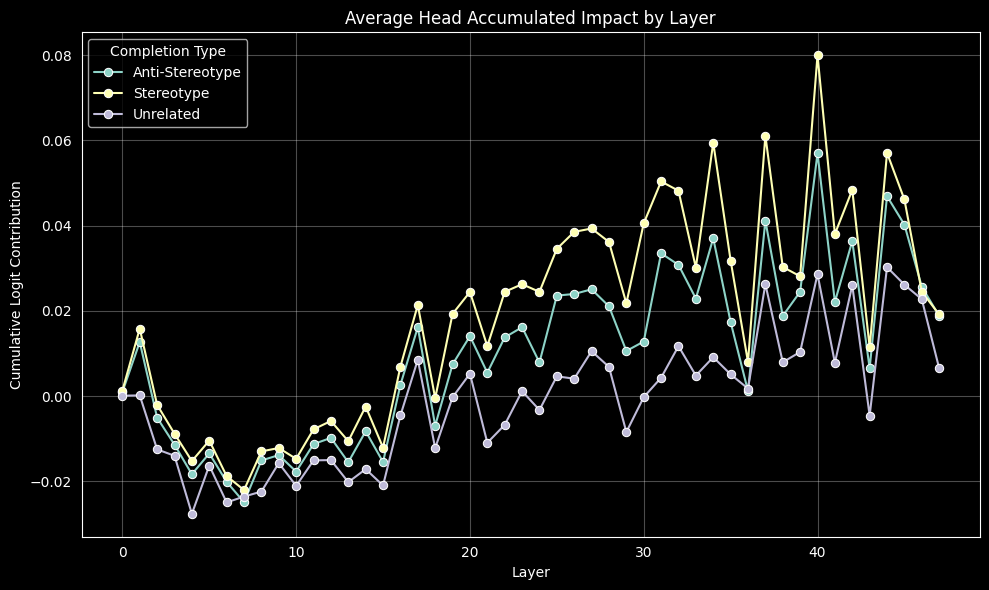

In [10]:
head_df = df[df['Component'].str.contains('Head')].copy()

# Calculate mean impact per layer per type
head_summary = head_df.groupby(['Layer', 'Type'])['Accumulated_Impact'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=head_summary, x='Layer', y='Accumulated_Impact', hue='Type', marker='o')
plt.title("Average Head Accumulated Impact by Layer")
plt.ylabel("Cumulative Logit Contribution")
plt.xlabel("Layer")
plt.grid(True, alpha=0.3)
plt.legend(title="Completion Type")
plt.tight_layout()
plt.show()